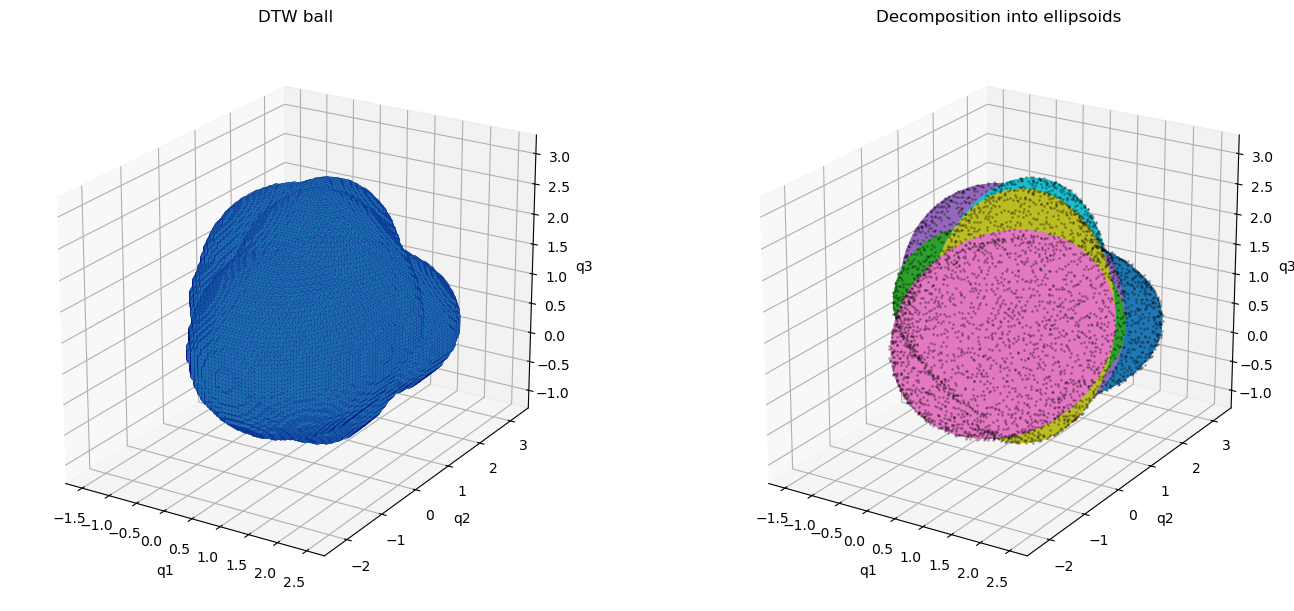

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba
from skimage import measure

# Example center and radius (edit these as needed)
P = np.array([0.5, 1.3, -0.2, 0.8, 1.0], dtype=float)
Delta = 2.2
m = 3
k = len(P)

if m != 3:
    raise ValueError("This visualization is configured for m = 3.")
if k < m:
    raise ValueError("Need k >= m so that all three blocks are non-empty.")


def decomposition_parts_m3(series, delta):
    """Return all ellipsoids for the exact DTW-ball decomposition when d=1 and m=3."""
    parts = []
    for t1 in range(1, len(series) - 1):
        for t2 in range(t1 + 1, len(series)):
            blocks = [series[:t1], series[t1:t2], series[t2:]]
            sizes = np.array([len(block) for block in blocks], dtype=float)
            centers = np.array([block.mean() for block in blocks], dtype=float)
            C_w = float(
                sum(
                    np.sum(block**2) - (np.sum(block) ** 2) / len(block)
                    for block in blocks
                )
            )
            rhs = delta**2 - C_w
            if rhs >= 0:
                radii = np.sqrt(rhs / sizes)
                parts.append(
                    {
                        "splits": (t1, t2),
                        "sizes": sizes,
                        "centers": centers,
                        "C_w": C_w,
                        "rhs": rhs,
                        "radii": radii,
                    }
                )
    return parts


parts = decomposition_parts_m3(P, Delta)
if not parts:
    raise ValueError("No non-empty ellipsoids for this P, m, and Delta. Increase Delta.")

# Build plotting domain from ellipsoid bounds
mins = np.min([part["centers"] - part["radii"] for part in parts], axis=0) - 0.3
maxs = np.max([part["centers"] + part["radii"] for part in parts], axis=0) + 0.3

grid_size = 80
q1_vals = np.linspace(mins[0], maxs[0], grid_size)
q2_vals = np.linspace(mins[1], maxs[1], grid_size)
q3_vals = np.linspace(mins[2], maxs[2], grid_size)
q1, q2, q3 = np.meshgrid(q1_vals, q2_vals, q3_vals, indexing="ij")

# Exact DTW ball via ellipsoid decomposition (not via direct DTW dynamic programming)
dtw_ball_mask = np.zeros_like(q1, dtype=bool)
for part in parts:
    center = part["centers"]
    size = part["sizes"]
    rhs = part["rhs"]
    quad_form = (
        size[0] * (q1 - center[0]) ** 2
        + size[1] * (q2 - center[1]) ** 2
        + size[2] * (q3 - center[2]) ** 2
    )
    dtw_ball_mask |= quad_form <= rhs

spacing = (q1_vals[1] - q1_vals[0], q2_vals[1] - q2_vals[0], q3_vals[1] - q3_vals[0])
verts, faces, _, _ = measure.marching_cubes(dtw_ball_mask.astype(float), level=0.5, spacing=spacing)
verts += np.array([q1_vals[0], q2_vals[0], q3_vals[0]])
boundary_step = max(1, len(verts) // 3500)
boundary_points = verts[::boundary_step]

fig = plt.figure(figsize=(14, 6), constrained_layout=True)
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax2 = fig.add_subplot(1, 2, 2, projection="3d")

# Left: exact DTW ball via decomposition
ax1.plot_trisurf(
    verts[:, 0],
    verts[:, 1],
    verts[:, 2],
    triangles=faces,
    color=to_rgba("tab:blue", 0.22),
    edgecolor=to_rgba("navy", 0.65),
    linewidth=0.12,
    antialiased=True,
    shade=False,
    alpha=1.0,
    zorder=2,
)
ax1.set_title("DTW ball")

# Right: individual ellipsoids + DTW-ball boundary
colors = plt.cm.tab10(np.linspace(0, 1, len(parts)))
u = np.linspace(0, 2 * np.pi, 48)
v = np.linspace(0, np.pi, 24)

for color, part in zip(colors, parts):
    center = part["centers"]
    radii = part["radii"]
    x = center[0] + radii[0] * np.outer(np.cos(u), np.sin(v))
    y = center[1] + radii[1] * np.outer(np.sin(u), np.sin(v))
    z = center[2] + radii[2] * np.outer(np.ones_like(u), np.cos(v))

    ax2.plot_surface(
        x,
        y,
        z,
        color=to_rgba(color, 0.12),
        edgecolor=to_rgba(color, 0.55),
        linewidth=0.25,
        shade=False,
        alpha=1.0,
        zorder=1,
    )

ax2.scatter(
    boundary_points[:, 0],
    boundary_points[:, 1],
    boundary_points[:, 2],
    s=1.2,
    color=to_rgba("black", 0.22),
    depthshade=False,
    zorder=3,
    label="_nolegend_",
)
ax2.set_title("Decomposition into ellipsoids")

for ax in (ax1, ax2):
    ax.set_xlim(mins[0], maxs[0])
    ax.set_ylim(mins[1], maxs[1])
    ax.set_zlim(mins[2], maxs[2])
    ax.set_xlabel("q1")
    ax.set_ylabel("q2")
    ax.set_zlabel("q3")
    ax.set_box_aspect((maxs[0] - mins[0], maxs[1] - mins[1], maxs[2] - mins[2]))
    ax.grid(alpha=0.25)
    ax.view_init(elev=22, azim=-58)

plt.show()